# <center><font color="#615FFF" size="8"> Hackathon Oracle – Análisis y Predicción de Churn </font></center>


In [37]:
# ===============================
# Imports generales
# ===============================

import os
import math
import joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Scikit-learn
# ===============================

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

#  

----
# <center><font color="#615FFF" size="6">1. Carga de Datos </font></center>
----

In [38]:
data = pd.read_excel("/content/data.xlsx")

In [39]:
data.shape

(7043, 21)

In [40]:
data.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6128,3317-VLGQT,Female,0,Yes,No,14,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,78.10,1122.40,No
3414,4837-PZTIC,Female,0,No,No,47,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,Two year,No,Mailed check,41.90,1875.25,No
3936,0701-TJSEF,Male,0,No,No,9,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Month-to-month,Yes,Bank transfer (automatic),68.25,576.95,No
4675,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
6037,7537-CBQUZ,Male,1,No,No,63,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),109.40,7031.45,No


In [41]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [42]:
data.rename(columns={
    'customerID': 'id_cliente',
    'gender': 'genero',
    'SeniorCitizen': 'adulto_mayor',
    'Partner': 'tiene_pareja',
    'Dependents': 'tiene_dependientes',
    'tenure': 'antiguedad_meses',
    'PhoneService': 'servicio_telefono',
    'MultipleLines': 'lineas_multiples',
    'InternetService': 'servicio_internet',
    'OnlineSecurity': 'seguridad_en_linea',
    'OnlineBackup': 'respaldo_en_linea',
    'DeviceProtection': 'proteccion_dispositivo',
    'TechSupport': 'soporte_tecnico',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_peliculas',
    'Contract': 'tipo_contrato',
    'PaperlessBilling': 'facturacion_electronica',
    'PaymentMethod': 'metodo_pago',
    'MonthlyCharges': 'cargo_mensual',
    'TotalCharges': 'cargos_totales',
    'Churn': 'abandono_cliente'
}, inplace=True)


In [43]:
data.sample(5)

,id_cliente,genero,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefono,lineas_multiples,servicio_internet,seguridad_en_linea,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_electronica,metodo_pago,cargo_mensual,cargos_totales,abandono_cliente
3694,1150-WFARN,Female,0,Yes,Yes,67,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),108.75,7156.20,Yes
124,7219-TLZHO,Female,0,Yes,Yes,4,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.85,62.90,No
944,6353-BRMMA,Female,0,Yes,Yes,54,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),104.10,5645.80,No
3182,6568-POCUI,Female,0,Yes,No,45,Yes,No,Fiber optic,No,...,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),95.20,4285.80,No
2890,1732-VHUBQ,Female,1,Yes,Yes,47,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),70.55,3309.25,Yes


In [44]:
# memoria de datos

round(data.memory_usage(deep=True).sum() / 1024**2, 3)

np.float64(6.506)

In [45]:
data.isnull().sum()

,0
id_cliente,0
genero,0
adulto_mayor,0
tiene_pareja,0
tiene_dependientes,0
antiguedad_meses,0
servicio_telefono,0
lineas_multiples,0
servicio_internet,0
seguridad_en_linea,0


#  

----
# <center><font color="#615FFF" size="6">2. Análisis Univariado </font></center>
----

In [46]:
# Tratar adulto_mayor como variable categórica
data['adulto_mayor'] = data['adulto_mayor'].astype(str)


In [47]:
cat_cols = data.select_dtypes(include="object").columns
num_cols = data.select_dtypes(exclude="object").columns

In [48]:
data[num_cols].describe()

,antiguedad_meses,cargo_mensual,cargos_totales
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000



### Distribución de variables numéricas


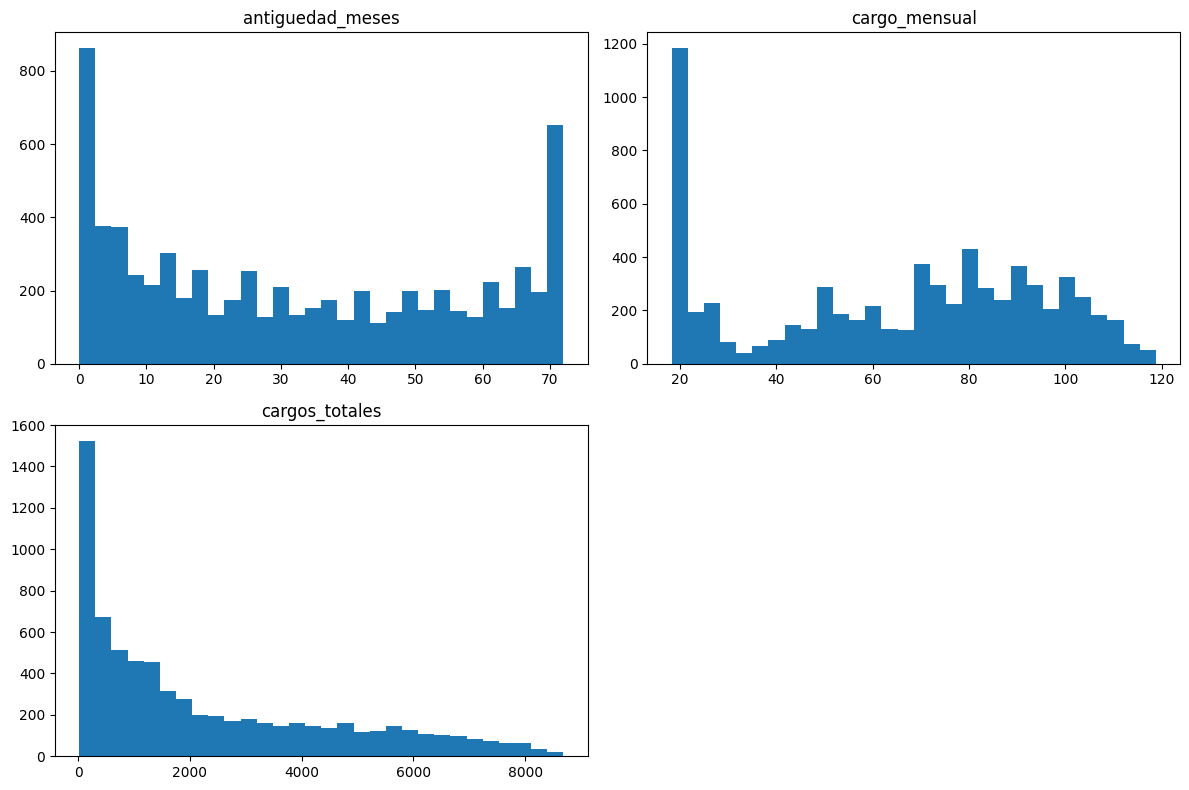

In [49]:

n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(data[col], bins=30)
    axes[i].set_title(col)

# Eliminar ejes vacíos
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Distribución de variables categóricas


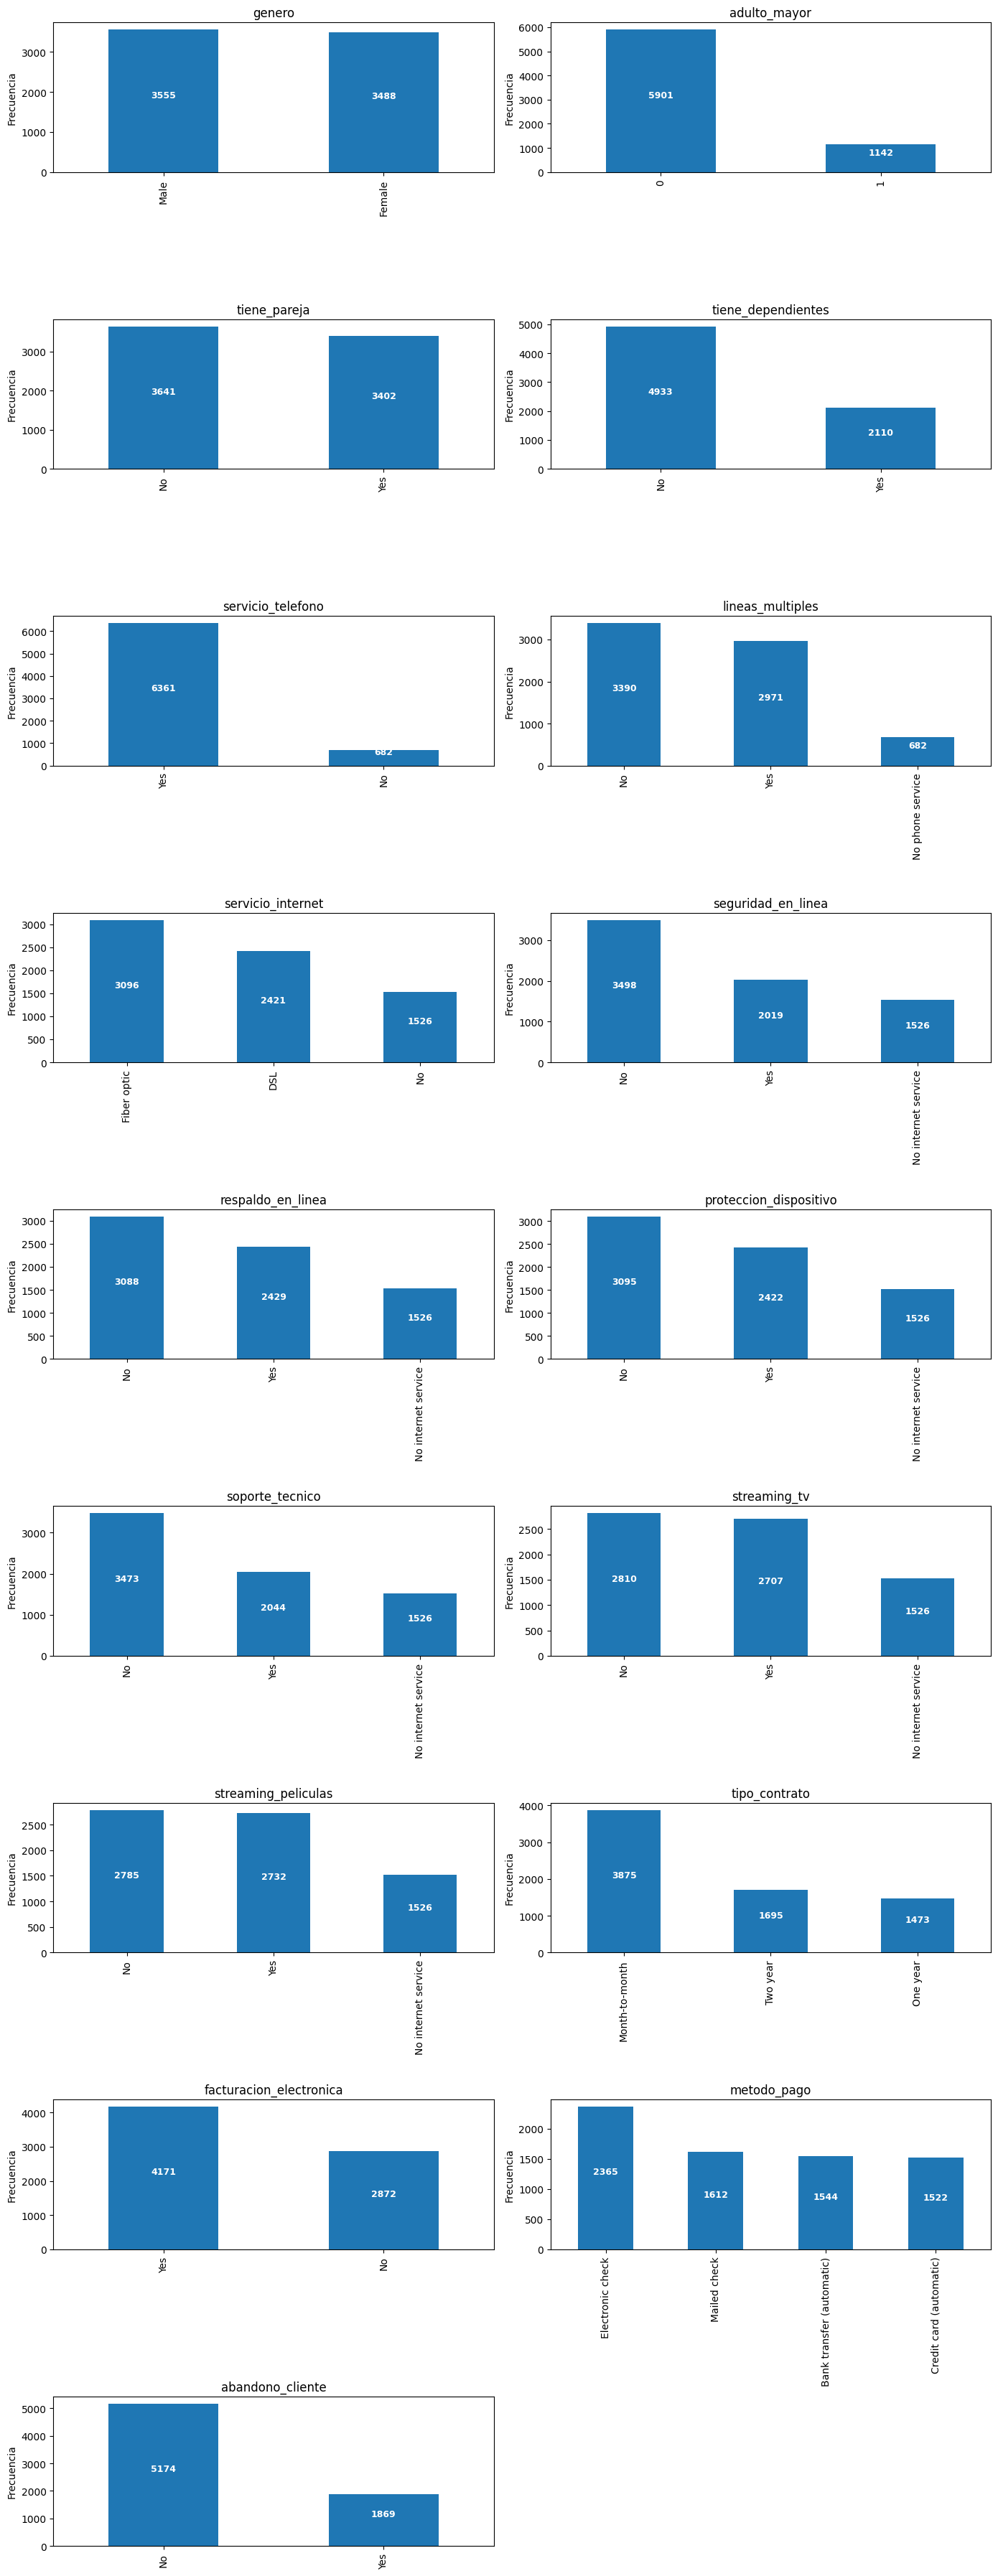

In [50]:

# Se excluye id_cliente por tener demasiados valores únicos

# Excluir columna
cat_cols_plot = [col for col in cat_cols if col != 'id_cliente']

n_cols = 2
n_rows = math.ceil(len(cat_cols_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
  #valores exactos
    value_counts = data[col].value_counts()

  #Gráfico
    ax =axes[i]
    bars = data[col].value_counts().plot(kind="bar", ax=axes[i])

  #Añadir los valores en las barras
    for rect in bars.patches:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2.,(height)/2 + 0.01 * max(value_counts),
                f'{int(height)}', ha='center', va='bottom', fontsize=9,color='white', fontweight='bold')


    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")

# Eliminar ejes vacíos
for j in range(len(cat_cols_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#  

----
# <center><font color="#615FFF" size="6">3. Análisis Bivariado </font></center>
----

### Proporción de abandono de clientes


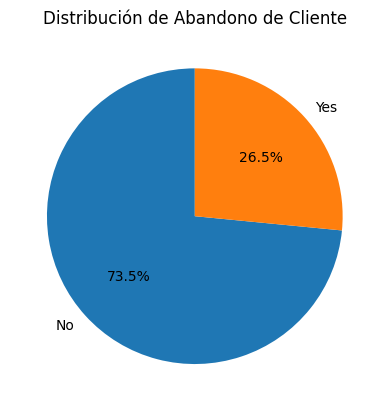

In [51]:
#Gráfico de Abandono de clientes
data['abandono_cliente'].value_counts(normalize=True).plot.pie(autopct='%1.1f%%', startangle=90)

plt.title('Distribución de Abandono de Cliente')
plt.ylabel('')
plt.show()

### Análisis bivariado – variables numéricas


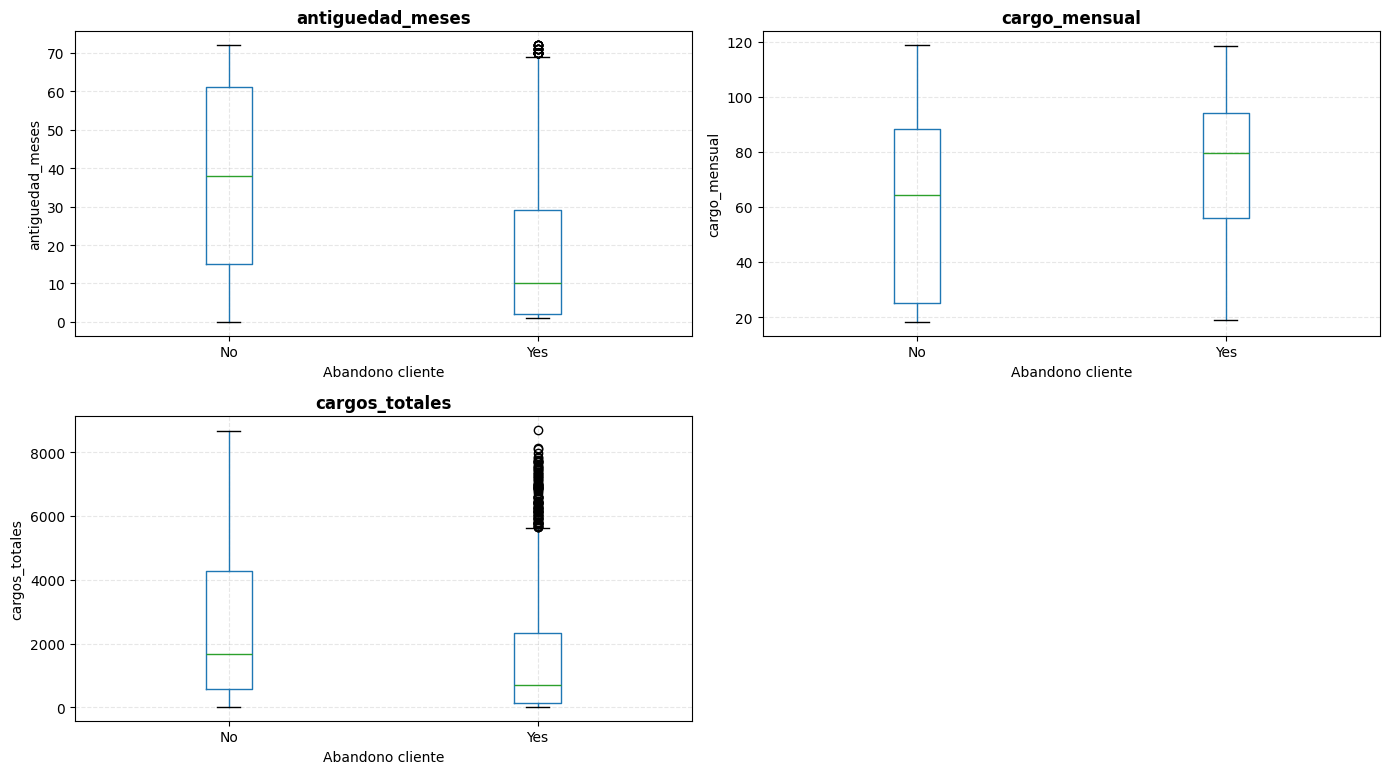

In [52]:

num_cols_plot = [col for col in num_cols if col != 'abandono_cliente']

n_cols = 2
n_rows = math.ceil(len(num_cols_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols_plot):
    ax = axes[i]

    data.boxplot(column=col, by='abandono_cliente', ax=axes[i])

    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel("Abandono cliente")
    axes[i].set_ylabel(col)

    ax.grid(True, alpha=0.3, linestyle='--')

plt.suptitle("")

# Eliminar ejes vacíos
for j in range(len(num_cols_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



### Análisis bivariado – variables categóricas


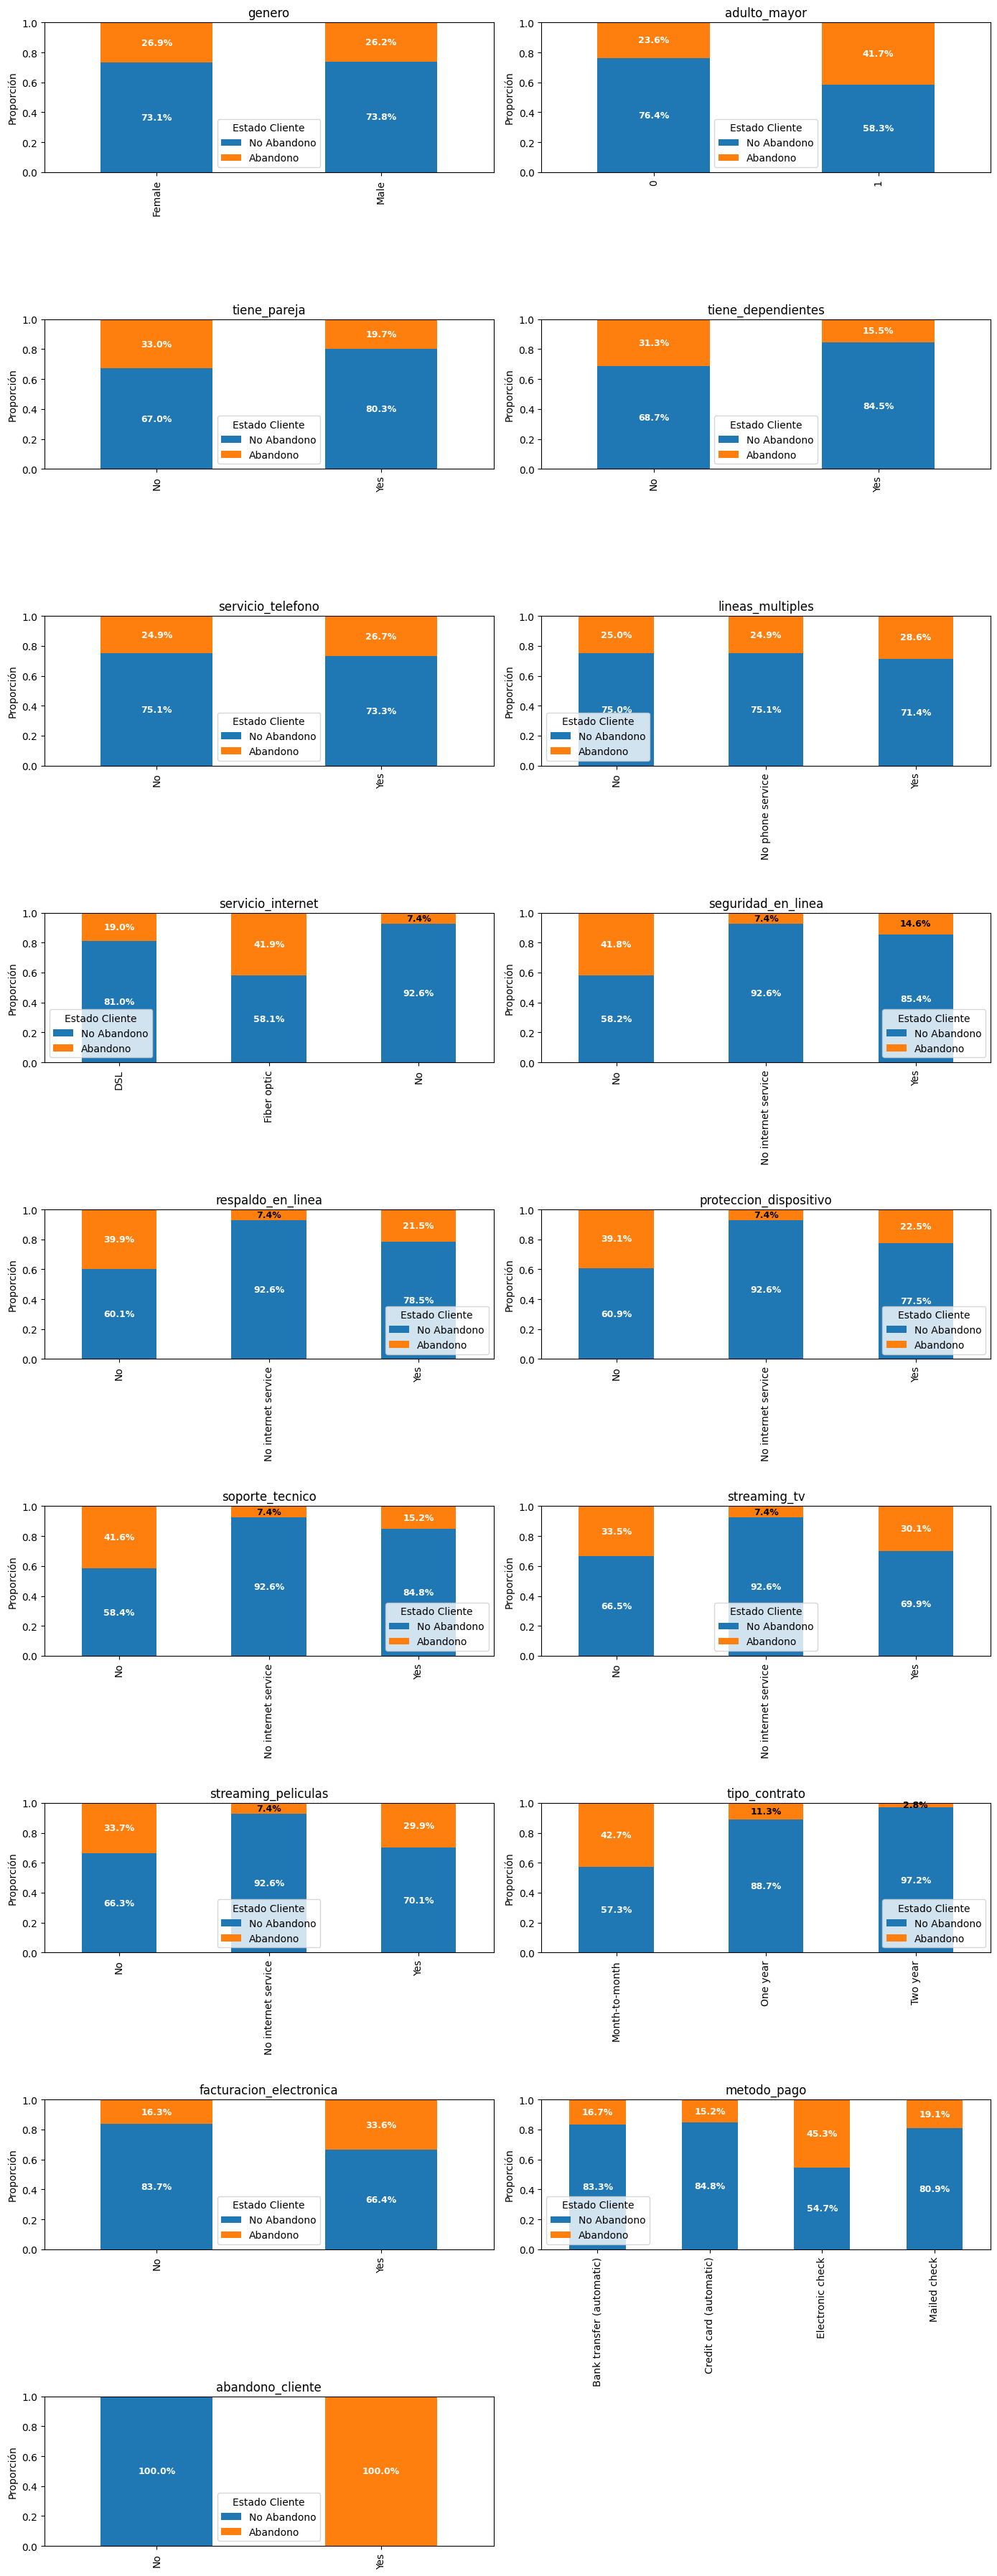

In [53]:

# Excluir id_cliente si aún está
cat_cols_plot = [col for col in cat_cols if col != 'id_cliente']

n_cols = 2
n_rows = math.ceil(len(cat_cols_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
    ax = axes[i]

    cross_tab= pd.crosstab(
        data[col],
        data['abandono_cliente'],
        normalize='index'
    )

    bars= cross_tab.plot(kind='bar', stacked=True, ax=ax)

    n_categories = len(cross_tab)
    bar_positions = np.arange(n_categories)

    cumulative_height = np.zeros(n_categories)

    for j, abandono_cat in enumerate(cross_tab.columns):
        values = cross_tab[abandono_cat].values

        for k in range(n_categories):
            value = values[k]
            if value > 0:
                y_pos = cumulative_height[k] + (value / 2)

                ax.text(
                    bar_positions[k],
                    y_pos,
                    f'{value:.1%}',
                    ha='center',
                    va='center',
                    fontsize=9,
                    fontweight='bold',
                    color='white' if value > 0.15 else 'black'
                )

        cumulative_height += values

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Proporción")

    if 'abandono_cliente' in data.columns:
        legend_labels = ['No Abandono', 'Abandono']
        ax.legend(legend_labels, title='Estado Cliente')

    ax.set_ylim(0, 1)

# Eliminar ejes vacíos
for j in range(len(cat_cols_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<center><font color="#615FFF" size="6">4. Feature Engineering</font></center>


In [54]:
# Antigüedad en años
data['antiguedad_años'] = data['antiguedad_meses'] / 12

# Eliminar id_cliente
data = data.drop('id_cliente', axis=1)

# Cliente con muchos servicios
servicios_cols = [
    'seguridad_en_linea', 'respaldo_en_linea', 'proteccion_dispositivo',
    'soporte_tecnico', 'streaming_tv', 'streaming_peliculas'
]

data['num_servicios'] = data[servicios_cols].apply(
    lambda x: (x == 'Yes').sum(), axis=1
)


In [55]:
# Convertir target a binario explícito
# Yes = 1 (abandona), No = 0 (no abandona)
data['abandono_cliente'] = data['abandono_cliente'].map({
    'Yes': 1,
    'No': 0
})


In [56]:
# Separar target
y = data['abandono_cliente']

# Dataset sin target
X = data.drop('abandono_cliente', axis=1)


###**Definir columnas**

In [57]:
num_cols = [
    'antiguedad_meses',
    'cargo_mensual',
    'cargos_totales',
    'num_servicios',
    'antiguedad_años'
]

cat_cols = X.select_dtypes(include='object').columns.tolist()


###**Transformadores**

In [58]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


###**ColumnTransformer**

In [59]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

> **Nota importante**  
> Las variables `num_servicios` y `antiguedad_años` **no forman parte del contrato de entrada**.  
> Se calculan internamente a partir de los campos recibidos desde el backend,  
> por lo que **el JSON de entrada no se modifica**.


---
<center><font color="#615FFF" size="6">5. Modelado y desbalance de clases</font></center>


---

### <font color="#615FFF">Modelo utilizado: Regresión Logística</font>

La **Regresión Logística** es un modelo de **clasificación binaria**, adecuado para este problema, ya que el objetivo es predecir si un cliente:

- **Abandona el servicio (1)**
- **Permanece en la compañía (0)**


Este modelo permite estimar la probabilidad de abandono del cliente a partir de sus características, después de realizar el **balanceo de clases**, la **ingeniería de características** y el **preprocesamiento de los datos**.



###**Modelo**

In [60]:

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

###**Pipeline completo**

In [61]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

---
<center><font color="#615FFF" size="6">6. TRAIN / TEST</font></center>

---


In [62]:
# Validación de columnas esperadas (contrato con backend)
# Columnas esperadas desde el backend (contrato de entrada)
expected_features = set([
    'genero',
    'adulto_mayor',
    'tiene_pareja',
    'tiene_dependientes',
    'antiguedad_meses',
    'servicio_telefono',
    'lineas_multiples',
    'servicio_internet',
    'seguridad_en_linea',
    'respaldo_en_linea',
    'proteccion_dispositivo',
    'soporte_tecnico',
    'streaming_tv',
    'streaming_peliculas',
    'tipo_contrato',
    'facturacion_electronica',
    'metodo_pago',
    'cargo_mensual',
    'cargos_totales'
])


def validar_input(df):
    missing = expected_features - set(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas en el input: {missing}")


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['antiguedad_meses',
                                                   'cargo_mensual',
                                                   'cargos_totales',
                                                   'num_servicios',
                                                   'antiguedad_años']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder...
                                                   'tiene_pareja',
                                                   'tiene_dependientes',
                                                   'servicio_telefono',
                                                   'lineas_multiples',
                                                   'servicio_internet',
                                                   'seguridad_en_linea',
                                                   'respaldo_en_linea',
                                                   'proteccion_dispositivo',
                                                   'soporte_tecnico',
                                                   'streaming_tv',
                                                   'streaming_peliculas',
                                                   'tipo_contrato',
                                                   'facturacion_electronica',
                                                   'metodo_pago'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

---
<center><font color="#615FFF" size="6">7. Evaluación</font></center>

---

In [64]:

y_pred = pipeline.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[949 345]
 [ 95 372]]
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1294
           1       0.52      0.80      0.63       467

    accuracy                           0.75      1761
   macro avg       0.71      0.76      0.72      1761
weighted avg       0.81      0.75      0.76      1761



---
<center><font color="#615FFF" size="6">8. GRIDSEARCH</font></center>

---

In [65]:

param_grid = {
    'classifier__C': [0.1, 1, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

final_model = grid.best_estimator_


---
<center><font color="#615FFF" size="6">9. Serialización Final</font></center>

---

In [66]:
# Crear carpeta models si no existe
os.makedirs("models", exist_ok=True)

joblib.dump(final_model, "models/churn_model_v1.joblib")

['models/churn_model_v1.joblib']

---
<center><font color="#615FFF" size="6">10. Función de Predicción</font></center>

---

In [67]:
# Función pensada para consumo desde backend

def predecir_churn(input_json):
    df = pd.DataFrame([input_json])

    validar_input(df)

    # Asegurar tipos consistentes
    df['adulto_mayor'] = df['adulto_mayor'].astype(str)

    # Feature engineering replicado
    df['num_servicios'] = df[[
        'seguridad_en_linea',
        'respaldo_en_linea',
        'proteccion_dispositivo',
        'soporte_tecnico',
        'streaming_tv',
        'streaming_peliculas'
    ]].apply(lambda x: (x == 'Yes').sum(), axis=1)

    df['antiguedad_años'] = df['antiguedad_meses'] / 12

    pred = final_model.predict(df)[0]
    prob = final_model.predict_proba(df)[0][1]

    return {
        "abandono_cliente": bool(pred),
        "probabilidad_abandono": round(float(prob), 3)
    }

# Ejemplo de JSON de entrada


In [68]:
{
  "genero": "Male",
  "adulto_mayor": "0",
  "tiene_pareja": "Yes",
  "tiene_dependientes": "No",
  "antiguedad_meses": 12,
  "servicio_telefono": "Yes",
  "lineas_multiples": "No",
  "servicio_internet": "Fiber optic",
  "seguridad_en_linea": "No",
  "respaldo_en_linea": "Yes",
  "proteccion_dispositivo": "No",
  "soporte_tecnico": "No",
  "streaming_tv": "Yes",
  "streaming_peliculas": "Yes",
  "tipo_contrato": "Month-to-month",
  "facturacion_electronica": "Yes",
  "metodo_pago": "Electronic check",
  "cargo_mensual": 85.5,
  "cargos_totales": 1026.0
}

{'genero': 'Male',
 'adulto_mayor': '0',
 'tiene_pareja': 'Yes',
 'tiene_dependientes': 'No',
 'antiguedad_meses': 12,
 'servicio_telefono': 'Yes',
 'lineas_multiples': 'No',
 'servicio_internet': 'Fiber optic',
 'seguridad_en_linea': 'No',
 'respaldo_en_linea': 'Yes',
 'proteccion_dispositivo': 'No',
 'soporte_tecnico': 'No',
 'streaming_tv': 'Yes',
 'streaming_peliculas': 'Yes',
 'tipo_contrato': 'Month-to-month',
 'facturacion_electronica': 'Yes',
 'metodo_pago': 'Electronic check',
 'cargo_mensual': 85.5,
 'cargos_totales': 1026.0}

### Ejemplo de salida


In [69]:
{
  "abandono_cliente": true,
 "probabilidad_abandono": 0.742
}

NameError: name 'true' is not defined

### Cierre

El modelo queda entrenado, serializado y preparado para ser consumido por un servicio backend mediante JSON.
